In [23]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [24]:
df = pd.read_csv('Untitled Folder/train.csv')
test = pd.read_csv('Untitled Folder/test.csv')

In [25]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [27]:
df.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


In [41]:
df.isnull().sum() # There is no null value 

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

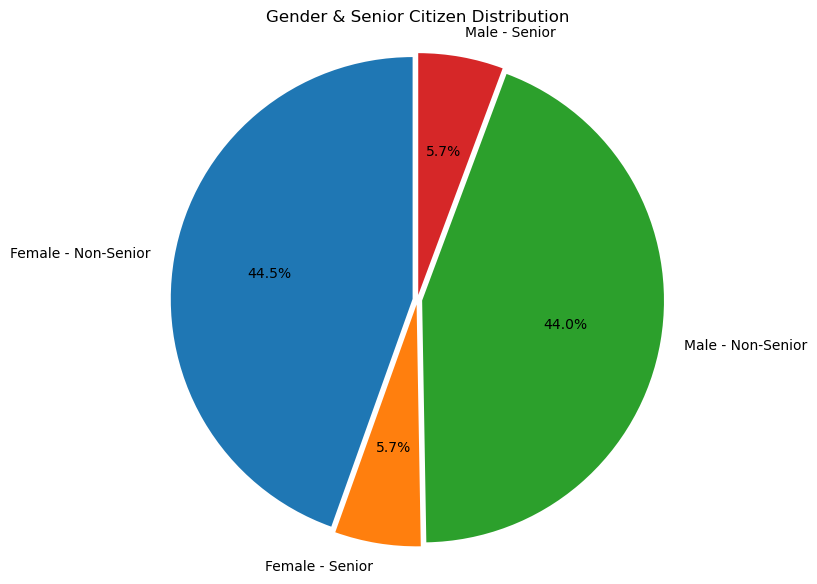

In [29]:
import matplotlib.pyplot as plt

# Create grouped counts
counts = df.groupby(['gender', 'SeniorCitizen']).size()

# Create labels
labels = [
    f"{gender} - {'Senior' if sc == 1 else 'Non-Senior'}"
    for gender, sc in counts.index
]

# Plot pie chart
plt.figure(figsize=(7,7))
plt.pie(
    counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    explode=[0.02]*len(counts)
)

plt.title('Gender & Senior Citizen Distribution')
plt.axis('equal')
plt.show()

<Axes: xlabel='tenure', ylabel='Count'>

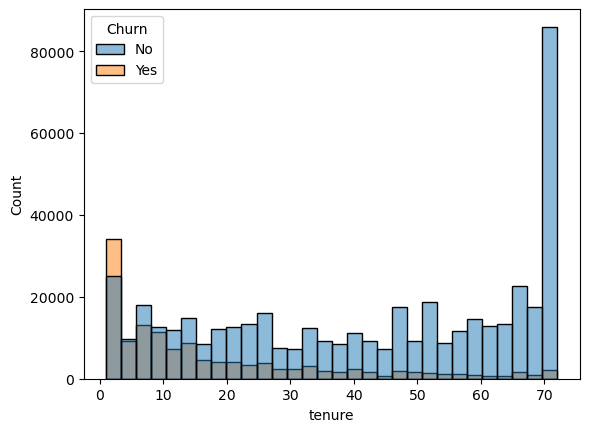

In [30]:
# Why Tenure is Important (VERY IMPORTANT for ML)

# In churn prediction:

# 🔴 Low tenure → High churn probability
# 🟢 High tenure → Low churn probability
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

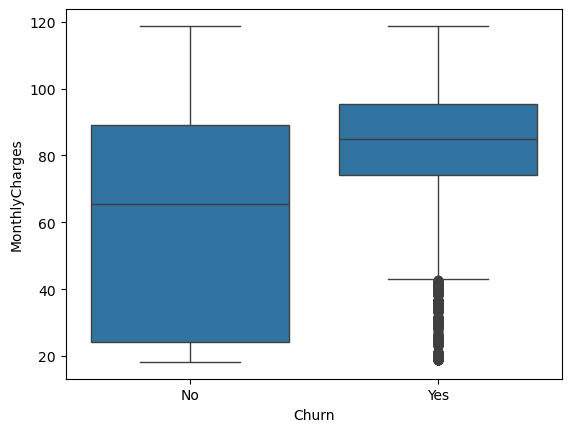

In [31]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

<Axes: xlabel='Churn', ylabel='TotalCharges'>

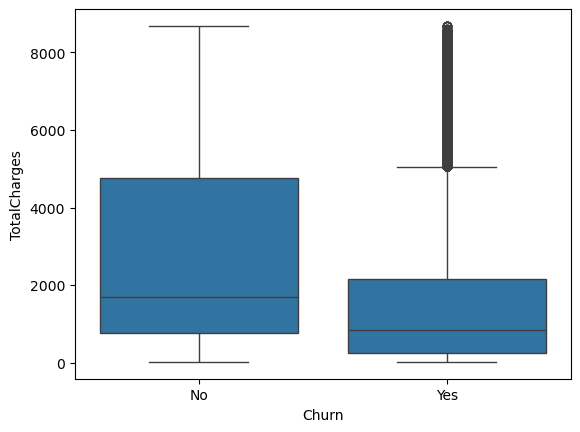

In [32]:
sns.boxplot(x='Churn', y='TotalCharges', data=df)

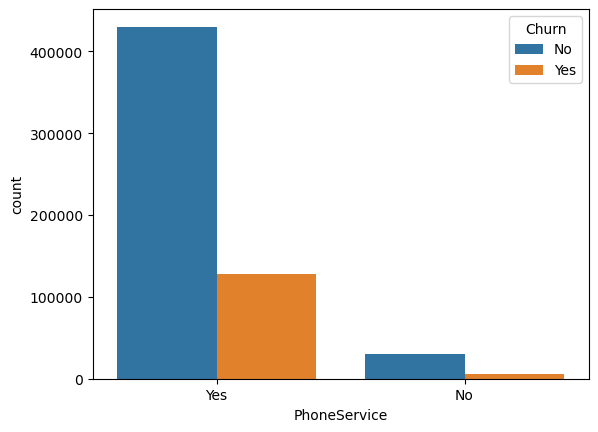

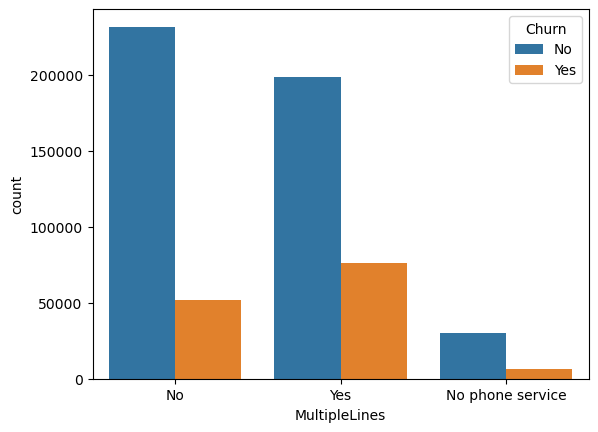

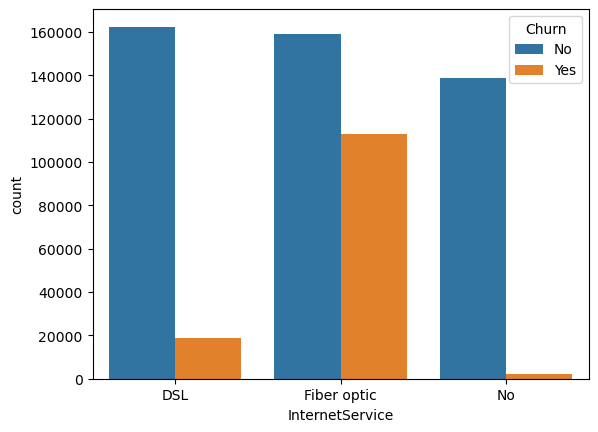

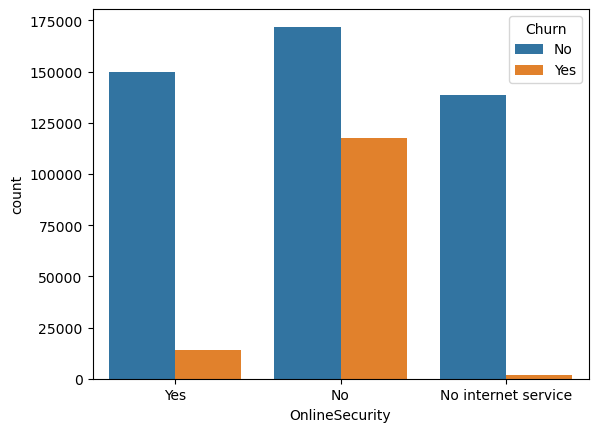

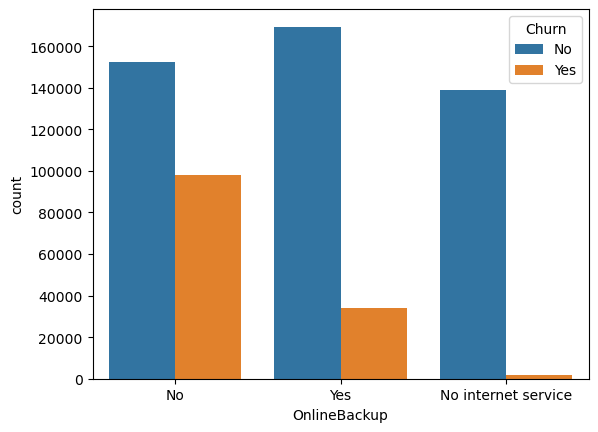

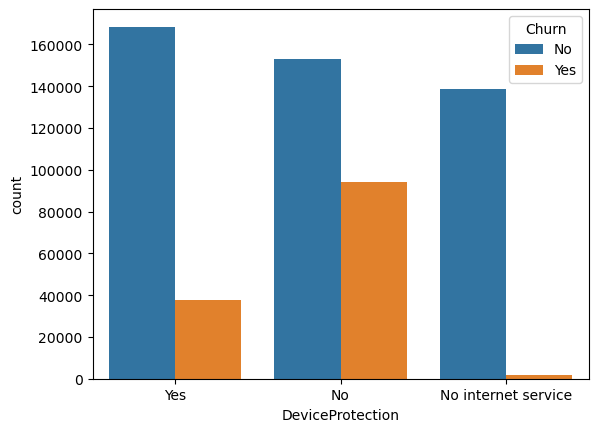

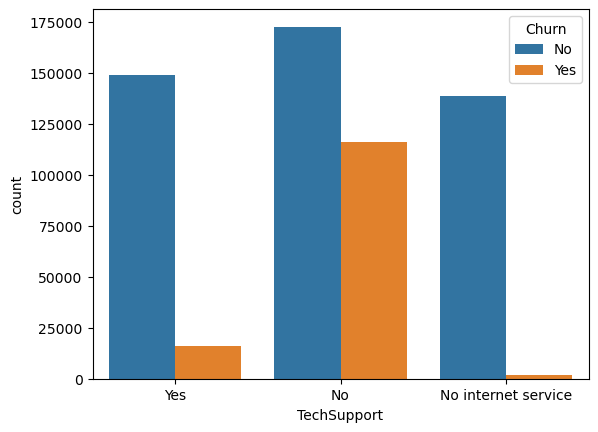

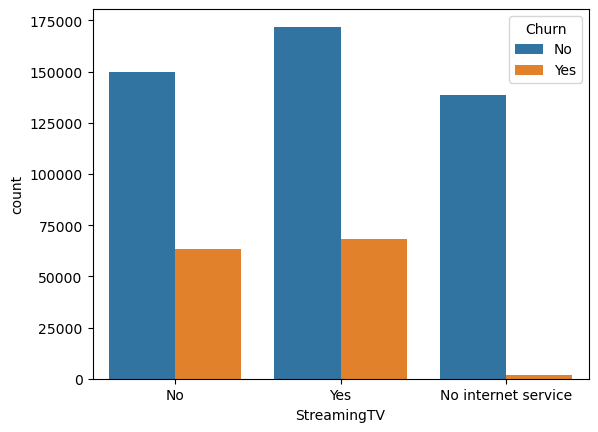

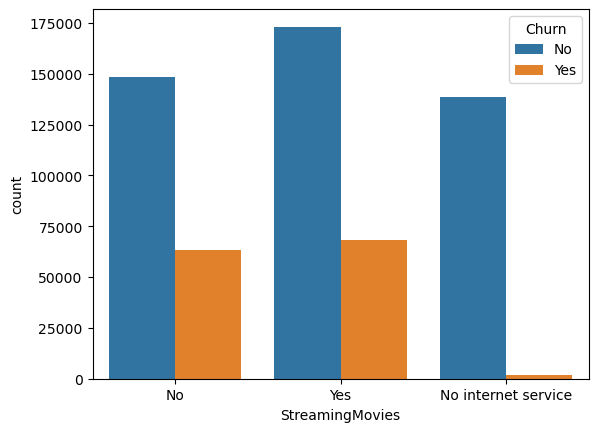

In [33]:
cols = [
    'PhoneService','MultipleLines','InternetService',
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

for col in cols:
    sns.countplot(x=col, hue='Churn', data=df)
    plt.show()

<Axes: xlabel='Contract', ylabel='count'>

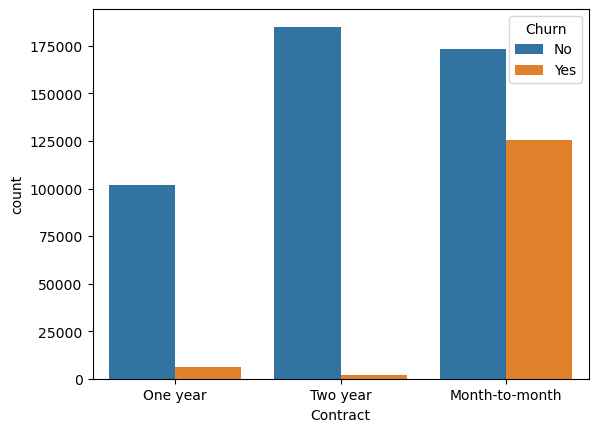

In [34]:
sns.countplot(x='Contract', hue='Churn', data=df)

<Axes: xlabel='PaymentMethod', ylabel='count'>

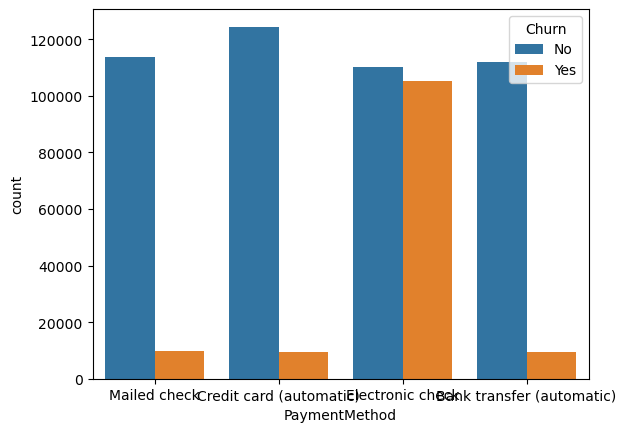

In [35]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

<Axes: xlabel='PaymentMethod', ylabel='count'>

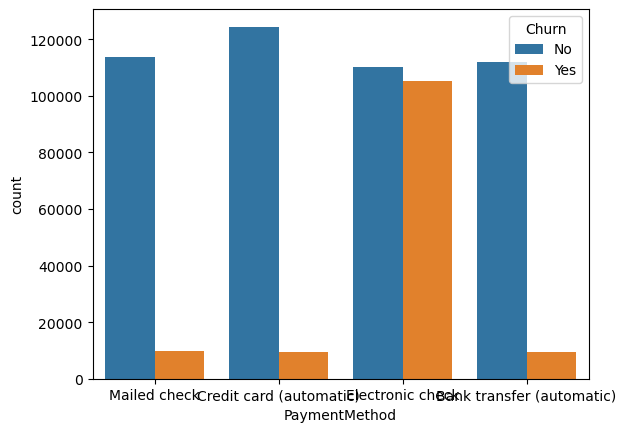

In [35]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)

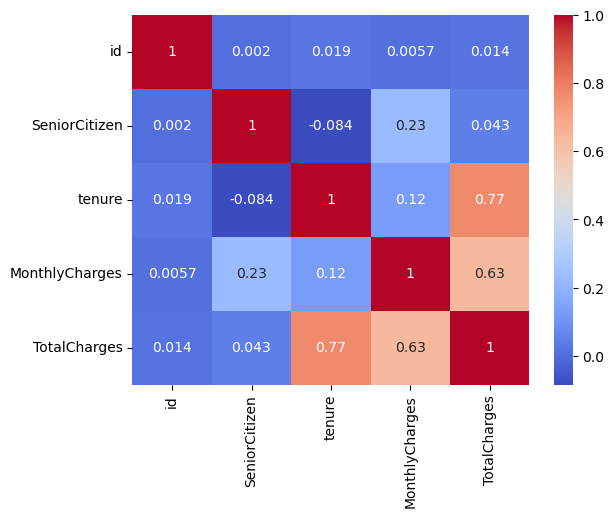

In [36]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [37]:
# to get unique value for better encoding
for i in df.columns:
    print(i,df[i].nunique())

id 594194
gender 2
SeniorCitizen 2
Partner 2
Dependents 2
tenure 72
PhoneService 2
MultipleLines 3
InternetService 3
OnlineSecurity 3
OnlineBackup 3
DeviceProtection 3
TechSupport 3
StreamingTV 3
StreamingMovies 3
Contract 3
PaperlessBilling 2
PaymentMethod 4
MonthlyCharges 1921
TotalCharges 31910
Churn 2


In [38]:
# to get unique value for better encoding
for i in df.columns:
    print(i,df[i].unique())

id [     0      1      2 ... 594191 594192 594193]
gender ['Male' 'Female']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['Yes' 'No']
tenure [29 58  1 24 72 55 13 67 33 63  3 31 27 52 68 35 66 17 59 61 12 37 64 23
  9  8 15 18 19 51  5 71 60 62 45 69 40 53 54 34  2 70 39 41  4 22 46 28
 42 48 21 43 14 10 47  7 57 36 16 26 20 50 30 11 44 25 56  6 65 38 49 32]
PhoneService ['Yes' 'No']
MultipleLines ['No' 'Yes' 'No phone service']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['Yes' 'No' 'No internet service']
OnlineBackup ['No' 'Yes' 'No internet service']
DeviceProtection ['Yes' 'No' 'No internet service']
TechSupport ['Yes' 'No' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['One year' 'Two year' 'Month-to-month']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Mailed check' 'Credit card (automatic)' 'Electronic check'
 'Bank transfer (automatic)']
MonthlyCharges [ 60.1   69.5  100.4  

In [39]:
df['gender'] = df['gender'].map({"Female" : 0, "Male" : 1})

In [40]:
df['Partner'] = df['Partner'].map({"No" : 0, "Yes" :1})
df['Dependents'] = df['Dependents'].map({"No" : 0, "Yes" :1})
df['PhoneService'] = df['PhoneService'].map({"No" : 0, "Yes" :1})
df['PaperlessBilling'] = df['PaperlessBilling'].map({"No" : 0, "Yes" :1})
df['Churn'] = df['Churn'].map({"No" : 0, "Yes" :1})

In [42]:
df.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [43]:
df['MultipleLines'] = df['MultipleLines'].map({"No":0,"No phone service":0,"Yes":1})

In [46]:
binary_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for i in binary_cols:
    df[i] = df[i].replace("No internet service","No")
    df[i] = df[i].map({"No":0,"Yes":1})

In [47]:
df[binary_cols].isnull().sum()

OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

In [54]:
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,1,29,1,0,1,0,...,60.10,1653.85,0,False,False,True,False,False,False,True
1,1,1,0,1,1,58,1,0,1,1,...,69.50,3778.20,0,False,False,False,True,True,False,False
2,2,1,0,1,0,58,1,1,0,1,...,100.40,5841.35,0,True,False,False,False,False,True,False
3,3,0,0,0,0,1,1,0,0,0,...,69.70,70.70,1,True,False,False,False,False,True,False
4,4,0,0,0,0,1,1,0,0,0,...,70.45,70.45,1,True,False,False,False,False,True,False


In [50]:
df.groupby('InternetService')['Churn'].mean()

InternetService
DSL            0.103064
Fiber optic    0.415366
No             0.014311
Name: Churn, dtype: float64

In [51]:
df = pd.get_dummies(df,columns=['InternetService'],drop_first=True)

In [53]:
df = pd.get_dummies(df, columns=['Contract'], drop_first=True)
df = pd.get_dummies(df, columns=['PaymentMethod'], drop_first=True)

In [56]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 556.8 kB/s eta 0:00:02
   -------------- ------------------------- 0.5/1.5 MB 556.8 kB/s eta 0:00:02
   --------------------- ------------------ 0.8/1.5 MB 620.8 kB/s eta 0:00:02
   --------------------- ------------------ 0.8/1.5 MB 620.8 kB/s eta 0:00:02
   ---------------------------- ----------- 1.0/1.5 MB 617.9 kB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 617.9 kB/s eta 0:00:01
   ------------------------------------ --- 1.3/1.5 MB 625.7 kB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 618.3 kB/s eta 0:00:00


In [67]:
from lightgbm import LGBMClassifier as lgb
from sklearn.model_selection import train_test_split,cross_val_score,KFold
from sklearn.metrics import classification_report,accuracy_score

In [68]:
x = df.drop('Churn',axis=1)
y = df['Churn']

In [75]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [76]:
model = lgb(class_weight='balanced',max_depth=12,learning_rate=0.02,n_estimators=201)

In [77]:
model.fit(x_train,y_train) 
y_pred = model.predict(x_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 107054, number of negative: 368301
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029794 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 878
[LightGBM] [Info] Number of data points in the train set: 475355, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


In [79]:
test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [80]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.96      0.79      0.87     92076
           1       0.55      0.88      0.68     26763

    accuracy                           0.81    118839
   macro avg       0.76      0.84      0.77    118839
weighted avg       0.87      0.81      0.83    118839



In [82]:
y_pred_test = model.predict(test)

ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: gender: object, Partner: object, Dependents: object, PhoneService: object, MultipleLines: object, InternetService: object, OnlineSecurity: object, OnlineBackup: object, DeviceProtection: object, TechSupport: object, StreamingTV: object, StreamingMovies: object, Contract: object, PaperlessBilling: object, PaymentMethod: object